In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Set the directories for the training and validation datasets
train_dir = 'dataset/train'
val_dir = 'dataset/test'

In [3]:
# Set the parameters for the image preprocessing
img_width, img_height = 100, 100
batch_size = 32

In [4]:
# Create data generators to preprocess the images
train_datagen = ImageDataGenerator(rescale=1./255,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

In [5]:
train_generator = train_datagen.flow_from_directory(train_dir,
                                                    target_size=(img_width, img_height),
                                                    batch_size=batch_size,
                                                    class_mode='categorical')

Found 56 images belonging to 7 classes.


In [6]:
val_generator = val_datagen.flow_from_directory(val_dir,
                                                target_size=(img_width, img_height),
                                                batch_size=batch_size,
                                                class_mode='categorical')

Found 27 images belonging to 7 classes.


In [7]:
# Define the CNN architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(7, activation='softmax')
])

In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 98, 98, 32)        896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 49, 49, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 47, 47, 64)        18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 23, 23, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 21, 21, 128)       73856     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 10, 10, 128)       0         
_________________________________________________________________
flatten (Flatten)            (None, 12800)             0

In [9]:
# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [10]:
# Train the model
epochs = 50
history = model.fit(train_generator,
                    epochs=epochs,
                    validation_data=val_generator)

Epoch 1/50
2/2 [==============================] - 0s 234ms/step - loss: 2.1926 - accuracy: 0.1429 - val_loss: 1.9758 - val_accuracy: 0.1852
Epoch 2/50
2/2 [==============================] - 0s 96ms/step - loss: 1.9919 - accuracy: 0.0893 - val_loss: 1.9342 - val_accuracy: 0.1481
Epoch 3/50
2/2 [==============================] - 0s 92ms/step - loss: 1.9479 - accuracy: 0.1250 - val_loss: 1.9178 - val_accuracy: 0.2222
Epoch 4/50
2/2 [==============================] - 0s 98ms/step - loss: 1.9324 - accuracy: 0.1786 - val_loss: 1.9166 - val_accuracy: 0.2222
Epoch 5/50
2/2 [==============================] - 0s 92ms/step - loss: 1.9270 - accuracy: 0.2321 - val_loss: 1.9159 - val_accuracy: 0.2593
Epoch 6/50
2/2 [==============================] - 0s 91ms/step - loss: 1.9272 - accuracy: 0.1786 - val_loss: 1.9015 - val_accuracy: 0.2593
Epoch 7/50
2/2 [==============================] - 0s 118ms/step - loss: 1.9083 - accuracy: 0.2321 - val_loss: 1.8825 - val_accuracy: 0.2593
Epoch 8/50
2/2 [=========

In [11]:
# Save the trained model
model.save('cloth.h5')

In [12]:
# Plot the accuracy and loss curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

In [13]:
epochs_range = range(epochs)

Text(0.5, 1.0, 'Training and Validation Accuracy')

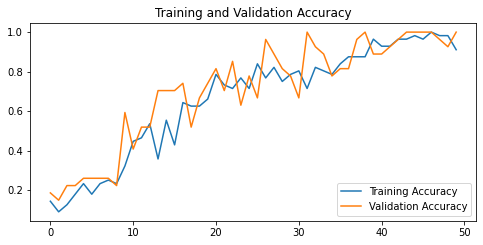

In [14]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

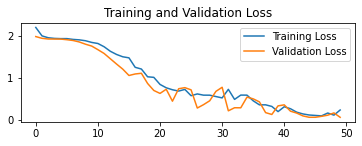

In [15]:
plt.subplot(2, 1, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

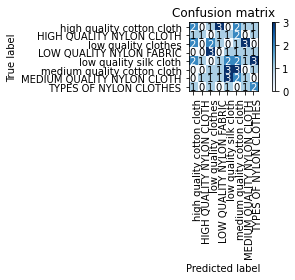

In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.utils.multiclass import unique_labels
import matplotlib.pyplot as plt

# Generate predictions and compute the confusion matrix
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
cm = confusion_matrix(val_generator.classes, y_pred)

# Define class labels
class_names = ['high quality cotton cloth', 'HIGH QUALITY NYLON CLOTH', 'low quality clothes', 'LOW QUALITY NYLON FABRIC','low quality silk cloth', 'medium quality cotton cloth', 'MEDIUM QUALITY NYLON CLOTH', 'TYPES OF NYLON CLOTHES']

# Plot the confusion matrix
fig, ax = plt.subplots()
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
# Set the x-axis and y-axis labels
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=class_names, yticklabels=class_names,
       xlabel='Predicted label', ylabel='True label')
# Rotate the x-axis labels to vertical orientation
plt.setp(ax.get_xticklabels(), rotation=90, ha="right",
         rotation_mode="anchor")
# Loop over the data and annotate each cell with its value
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2. else "black")
# Add a title to the plot
ax.set_title("Confusion matrix")
fig.tight_layout()
plt.show()


In [18]:
from sklearn.metrics import classification_report

# Generate predictions
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Get the class labels
class_labels = list(val_generator.class_indices.keys())

# Generate the classification report
report = classification_report(val_generator.classes, y_pred, target_names=class_labels)
print(report)


                             precision    recall  f1-score   support

   HIGH QUALITY NYLON CLOTH       0.12      0.10      0.11        10
   LOW QUALITY NYLON FABRIC       0.00      0.00      0.00         7
 MEDIUM QUALITY NYLON CLOTH       0.11      0.11      0.11         9
     TYPES OF NYLON CLOTHES       0.25      0.29      0.27         7
  high quality cotton cloth       0.45      0.42      0.43        12
        low quality clothes       0.08      0.11      0.09         9
     low quality silk cloth       0.00      0.00      0.00         9
medium quality cotton cloth       0.22      0.33      0.27         6

                   accuracy                           0.17        69
                  macro avg       0.15      0.17      0.16        69
               weighted avg       0.17      0.17      0.17        69



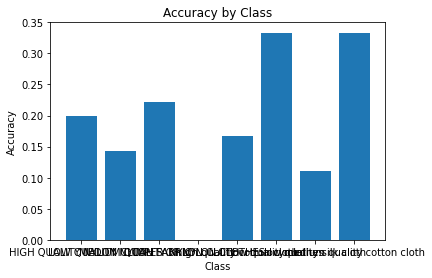

In [19]:
# Get the class labels
class_labels = list(val_generator.class_indices.keys())

# Get the class-wise accuracy values
class_wise_accuracy = cm.diagonal() / cm.sum(axis=1)

# Create a bar chart
plt.bar(class_labels, class_wise_accuracy)
plt.title('Accuracy by Class')
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.show()


In [20]:
# Evaluate the model on the validation data
_, accuracy = model.evaluate(val_generator)

# Print the validation accuracy
print('Validation Accuracy: %.2f' % (accuracy*100))


3/3 [==============================] - 0s 82ms/step - loss: 0.4771 - accuracy: 0.8696
Validation Accuracy: 86.96


In [21]:
# Get the accuracy from the history object
accuracy = history.history['accuracy'][-1]

# Print the accuracy to the console
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 84.05%
